In [ ]:
# === [TFM_newcodes] redireccion de figuras a la carpeta ./figures/ ===
# Celda anadida automaticamente: cualquier figura guardada con un nombre
# de fichero simple (sin carpeta) se guarda dentro de ./figures/.
# Las rutas que ya incluyen una carpeta (p.ej. 'figures/...') se respetan.
import os as _os
import matplotlib.pyplot as _plt
from matplotlib.figure import Figure as _Figure
_os.makedirs('figures', exist_ok=True)
def _fig_redirect(fname):
    try:
        p = _os.fspath(fname)
    except TypeError:
        return fname  # objeto tipo fichero/buffer: no tocar
    if _os.path.dirname(p) == '':
        p = _os.path.join('figures', p)
    d = _os.path.dirname(p)
    if d:
        _os.makedirs(d, exist_ok=True)
    return p
if not getattr(_plt.savefig, '_tfm_patched', False):
    _orig_plt_savefig = _plt.savefig
    _orig_fig_savefig = _Figure.savefig
    def _plt_savefig(fname, *a, **k):
        return _orig_plt_savefig(_fig_redirect(fname), *a, **k)
    _plt_savefig._tfm_patched = True
    def _fig_savefig(self, fname, *a, **k):
        return _orig_fig_savefig(self, _fig_redirect(fname), *a, **k)
    _plt.savefig = _plt_savefig
    _Figure.savefig = _fig_savefig
savefig = _plt.savefig  # por si se usa savefig(...) directamente


# Temporal Distribution by Rescaling — VagaRenfe dataset

Applies the **Time-Rescaling Theorem (TRT)** to inter-event times (IETs) from the `vagarenfe.json` dataset under three temporal conditions:

1. **Full lifespan** — all messages from the dataset
2. **Year 2024** — messages from 2024-01-01 to 2024-12-31
3. **2026 onwards** — messages from 2026-01-15 onward

For each condition both a **raw TPL** fit and a **KM finite-size-bias-corrected** fit are used, yielding **6 TRT exponential distributions**.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import kstest
from scipy.optimize import curve_fit
import powerlaw
from lifelines import KaplanMeierFitter

In [3]:
# Load dataset
df = pd.read_json("../../Datasets/vagarenfe.json")
df['date'] = pd.to_datetime(df['date'], utc=True)
df = df.sort_values('date').reset_index(drop=True)

print(f"Total messages: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Channels: {df['topic_name'].nunique()}")

Total messages: 92813
Date range: 2019-02-08 18:56:18+00:00 to 2026-04-28 15:40:35+00:00
Channels: 12


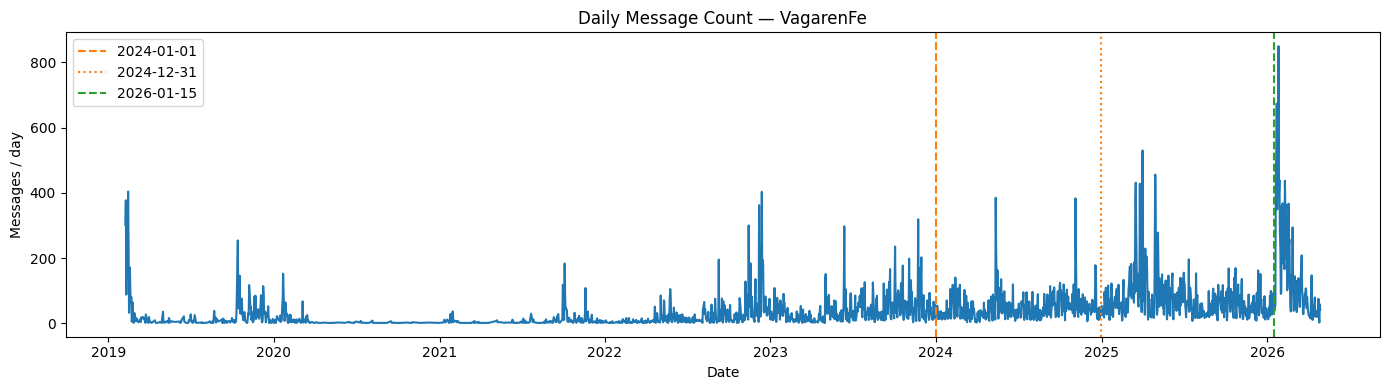

In [4]:
# Overview: daily message count across full lifespan
plt.figure(figsize=(14, 4))
df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size()
daily_counts.plot(kind='line')
plt.axvline(pd.Timestamp('2024-01-01').date(), color='C1', linestyle='--', label='2024-01-01')
plt.axvline(pd.Timestamp('2024-12-31').date(), color='C1', linestyle=':', label='2024-12-31')
plt.axvline(pd.Timestamp('2026-01-15').date(), color='C2', linestyle='--', label='2026-01-15')
plt.xlabel('Date')
plt.ylabel('Messages / day')
plt.title('Daily Message Count — VagarenFe')
plt.legend()
plt.tight_layout()
plt.show()

## Helper functions

In [5]:
def compute_iets(df_subset):
    """Compute positive inter-event times in seconds from a sorted DataFrame."""
    iets = df_subset['date'].diff().dt.total_seconds().dropna()
    return iets[iets > 0].values


def fit_tpl(iets):
    """Fit a truncated power law to IETs using the powerlaw package."""
    data = np.asarray(iets, dtype=float)
    data = data[np.isfinite(data) & (data > 0)]
    fit = powerlaw.Fit(data, discrete=False, verbose=False)
    tpl = fit.truncated_power_law
    return fit, tpl


def apply_trt(iets, tpl_model):
    """Apply Time-Rescaling Theorem: z = -log(1 - F(x)) should be Exp(1)."""
    xmin = float(getattr(tpl_model, 'xmin', np.nan))
    tail = iets[iets >= xmin]
    u = np.clip(np.asarray(tpl_model.cdf(tail), dtype=float), 1e-12, 1 - 1e-12)
    z = -np.log(1.0 - u)
    ks_stat, ks_p = kstest(z, 'expon')
    return z, ks_stat, ks_p, xmin, len(tail)


def km_survival(iets, cutoff_ts, last_msg_ts):
    """KM estimator with the last IET censored at cutoff."""
    last_censored = max(
        (pd.Timestamp(cutoff_ts) - pd.Timestamp(last_msg_ts)).total_seconds(), 0.0
    )
    durations = np.concatenate([iets, [last_censored]])
    events = np.concatenate([np.ones(len(iets), dtype=bool), [False]])
    kmf = KaplanMeierFitter()
    kmf.fit(durations, event_observed=events)
    km_t = kmf.survival_function_.index.values.astype(float)
    km_s = kmf.survival_function_['KM_estimate'].values.astype(float)
    return km_t, km_s


def fit_tpl_to_km(km_t, km_s, xmin):
    """Fit TPL survival S(t)/S(xmin) to the KM curve above xmin."""
    mask = (km_t >= xmin) & (km_s > 0)
    if mask.sum() < 5:
        return None, None
    s_at_xmin = float(np.interp(xmin, km_t, km_s))
    if s_at_xmin <= 0:
        return None, None
    t_tail = km_t[mask]
    s_norm = km_s[mask] / s_at_xmin

    def tpl_surv(t, alpha, lam):
        return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)

    try:
        popt, _ = curve_fit(
            tpl_surv, t_tail, s_norm,
            p0=[1.5, 1e-6],
            bounds=([1.001, 0.0], [20.0, np.inf]),
            maxfev=20_000
        )
        return popt, t_tail
    except Exception as e:
        print(f"  curve_fit failed: {e}")
        return None, None


def apply_trt_km(iets, xmin, alpha_km, lam_km):
    """Apply TRT using KM-fitted TPL parameters."""
    tail = iets[iets >= xmin]
    s_vals = (tail / xmin) ** (-(alpha_km - 1)) * np.exp(-(tail - xmin) * lam_km)
    s_vals = np.clip(s_vals, 0.0, 1.0)
    u = np.clip(1.0 - s_vals, 1e-12, 1 - 1e-12)
    z = -np.log(1.0 - u)
    ks_stat, ks_p = kstest(z, 'expon')
    return z, ks_stat, ks_p, len(tail)


def plot_trt(z, label, ax_hist, ax_qq, ax_loglog, color='steelblue'):
    """Plot histogram, Q-Q plot, and log-log density for rescaled intervals."""
    x = np.linspace(0, max(z) * 1.05, 300)

    ax_hist.hist(z, bins=50, density=True, alpha=0.6, color=color, edgecolor='k', linewidth=0.3)
    ax_hist.plot(x, stats.expon.pdf(x, scale=1), 'r-', lw=2, label='Exp(1)')
    ax_hist.set_xlabel('z')
    ax_hist.set_ylabel('Density')
    ax_hist.set_title(f'Histogram — {label}')
    ax_hist.legend()

    stats.probplot(z, dist=stats.expon, plot=ax_qq)
    ax_qq.set_title(f'Q-Q (exponential) — {label}')

    z_pos = z[z > 0]
    z_min_pos = max(np.min(z_pos), 1e-3)
    bins_ll = np.logspace(np.log10(z_min_pos), np.log10(np.max(z_pos)), 35)
    hist_ll, edges_ll = np.histogram(z_pos, bins=bins_ll, density=True)
    centers_ll = np.sqrt(edges_ll[:-1] * edges_ll[1:])
    mask_ll = hist_ll > 0
    ax_loglog.plot(centers_ll[mask_ll], hist_ll[mask_ll],
                   marker='o', linestyle='none', ms=5, color=color, label=label)
    x_ll = np.logspace(np.log10(z_min_pos), np.log10(np.max(z_pos)), 300)
    ax_loglog.plot(x_ll, stats.expon.pdf(x_ll, scale=1), 'k--', lw=2, label='Exp(1)')
    ax_loglog.set_xscale('log')
    ax_loglog.set_yscale('log')
    ax_loglog.set_xlabel('z (log)')
    ax_loglog.set_ylabel('Density (log)')
    ax_loglog.set_title(f'Log-Log — {label}')
    ax_loglog.legend()

## Define the three temporal conditions

In [6]:
conditions = {
    'Full lifespan': df.copy(),
    'Year 2024': df[
        (df['date'] >= pd.Timestamp('2024-01-01', tz='UTC')) &
        (df['date'] <= pd.Timestamp('2024-12-31 23:59:59', tz='UTC'))
    ].copy(),
    '2026 onwards': df[
        df['date'] >= pd.Timestamp('2026-01-15', tz='UTC')
    ].copy(),
}

for name, subset in conditions.items():
    print(f"{name}: {len(subset):,} messages  "
          f"({subset['date'].min().date()} → {subset['date'].max().date()})")

Full lifespan: 92,813 messages  (2019-02-08 → 2026-04-28)
Year 2024: 17,611 messages  (2024-01-01 → 2024-12-31)
2026 onwards: 15,550 messages  (2026-01-15 → 2026-04-28)


---
# Condition 1 — Full lifespan

In [7]:
df_full = conditions['Full lifespan']
iets_full = compute_iets(df_full)

print(f"IETs: {len(iets_full):,}")
print(f"Mean: {iets_full.mean():.1f} s  |  Median: {np.median(iets_full):.1f} s")
print(f"Min: {iets_full.min():.1f} s  |  Max: {iets_full.max():.1f} s")

IETs: 91,371
Mean: 2492.5 s  |  Median: 136.0 s
Min: 1.0 s  |  Max: 2550752.0 s


### 1a — Raw TPL fit

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


α = 1.7486   λ = 0.000003   xmin = 2360.0 s


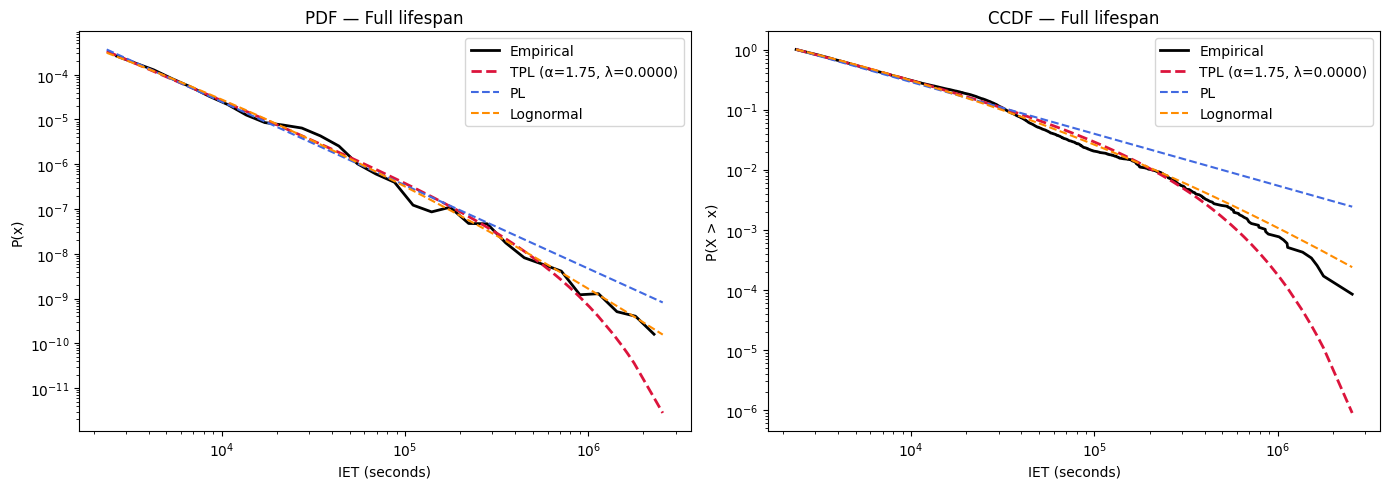

In [8]:
fit_full, tpl_full = fit_tpl(iets_full)

alpha_full = getattr(tpl_full, 'alpha', np.nan)
lambda_full = getattr(tpl_full, 'Lambda', np.nan)
xmin_full = float(getattr(tpl_full, 'xmin', np.nan))

print(f"α = {alpha_full:.4f}   λ = {lambda_full:.6f}   xmin = {xmin_full:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fit_full.plot_pdf(color='black', lw=2, label='Empirical', ax=axes[0])
tpl_full.plot_pdf(color='crimson', linestyle='--', lw=2,
                  label=f'TPL (α={alpha_full:.2f}, λ={lambda_full:.4f})', ax=axes[0])
fit_full.power_law.plot_pdf(color='royalblue', linestyle='--', lw=1.5, label='PL', ax=axes[0])
fit_full.lognormal.plot_pdf(color='darkorange', linestyle='--', lw=1.5, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('IET (seconds)')
axes[0].set_ylabel('P(x)')
axes[0].set_title('PDF — Full lifespan')
axes[0].legend()

fit_full.plot_ccdf(color='black', lw=2, label='Empirical', ax=axes[1])
tpl_full.plot_ccdf(color='crimson', linestyle='--', lw=2,
                   label=f'TPL (α={alpha_full:.2f}, λ={lambda_full:.4f})', ax=axes[1])
fit_full.power_law.plot_ccdf(color='royalblue', linestyle='--', lw=1.5, label='PL', ax=axes[1])
fit_full.lognormal.plot_ccdf(color='darkorange', linestyle='--', lw=1.5, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('IET (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF — Full lifespan')
axes[1].legend()
plt.tight_layout()
plt.show()

### 1b — TRT (raw)

Tail IETs (>= xmin=2360.0 s): 11796
KS test vs Exp(1): D = 0.0210,  p = 0.0001


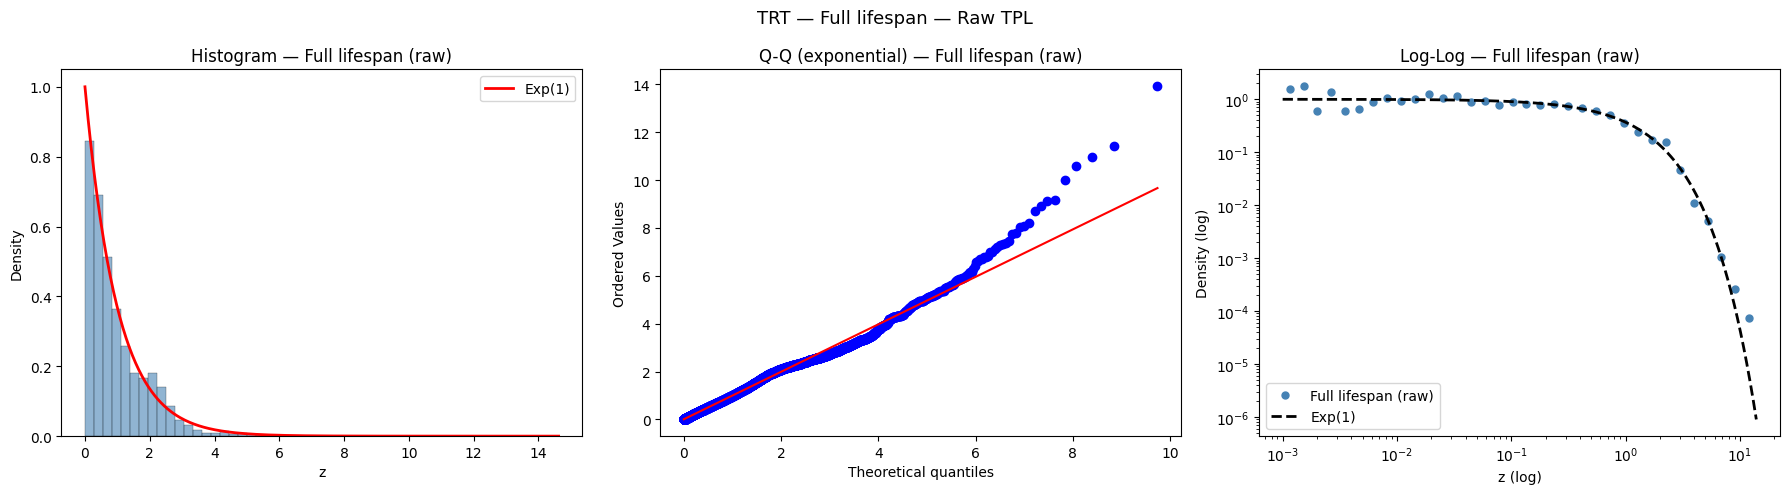

In [9]:
z_full_raw, ks_full_raw, ks_p_full_raw, xmin_used_full, n_tail_full = apply_trt(iets_full, tpl_full)

print(f"Tail IETs (>= xmin={xmin_used_full:.1f} s): {n_tail_full}")
print(f"KS test vs Exp(1): D = {ks_full_raw:.4f},  p = {ks_p_full_raw:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_trt(z_full_raw, 'Full lifespan (raw)', axes[0], axes[1], axes[2], color='steelblue')
plt.suptitle('TRT — Full lifespan — Raw TPL', fontsize=13)
plt.tight_layout()
plt.show()

### 1c — KM finite-size-bias correction

KM-fitted TPL: α = 1.7727,  λ = 0.000008


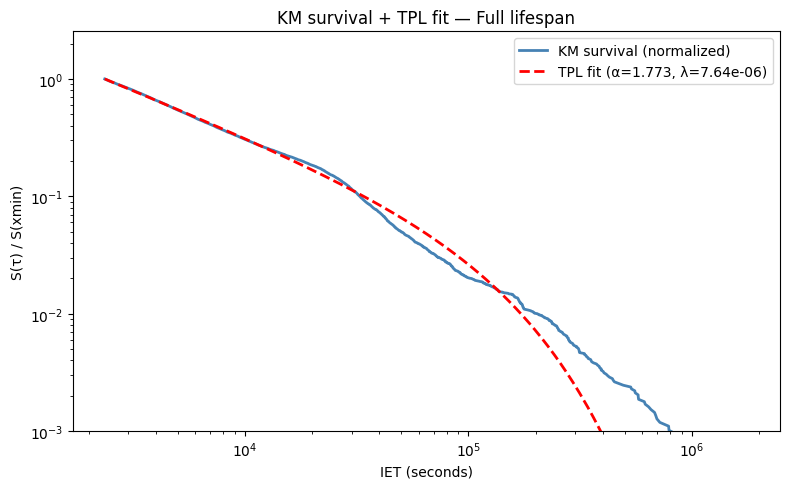

In [10]:
cutoff_full = df_full['date'].max()
last_msg_full = df_full['date'].iloc[-1]

km_t_full, km_s_full = km_survival(iets_full, cutoff_full, last_msg_full)
popt_full, t_tail_full = fit_tpl_to_km(km_t_full, km_s_full, xmin_full)

if popt_full is not None:
    alpha_km_full, lam_km_full = popt_full
    print(f"KM-fitted TPL: α = {alpha_km_full:.4f},  λ = {lam_km_full:.6f}")
else:
    print("KM TPL fit failed — check data or xmin.")

# Visualise KM survival vs fitted TPL
if popt_full is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    mask_km = (km_t_full >= xmin_full) & (km_s_full > 0)
    s_at_xmin_full = float(np.interp(xmin_full, km_t_full, km_s_full))
    ax.plot(km_t_full[mask_km], km_s_full[mask_km] / s_at_xmin_full,
            lw=2, color='steelblue', label='KM survival (normalized)')
    s_fit_full = (t_tail_full / xmin_full) ** (-(alpha_km_full - 1)) * np.exp(-(t_tail_full - xmin_full) * lam_km_full)
    ax.plot(t_tail_full, s_fit_full, 'r--', lw=2,
            label=f'TPL fit (α={alpha_km_full:.3f}, λ={lam_km_full:.2e})')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-3)
    ax.set_xlabel('IET (seconds)')
    ax.set_ylabel('S(τ) / S(xmin)')
    ax.set_title('KM survival + TPL fit — Full lifespan')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 1d — TRT (KM-corrected)

Tail IETs: 11796
KS test vs Exp(1): D = 0.0178,  p = 0.0011


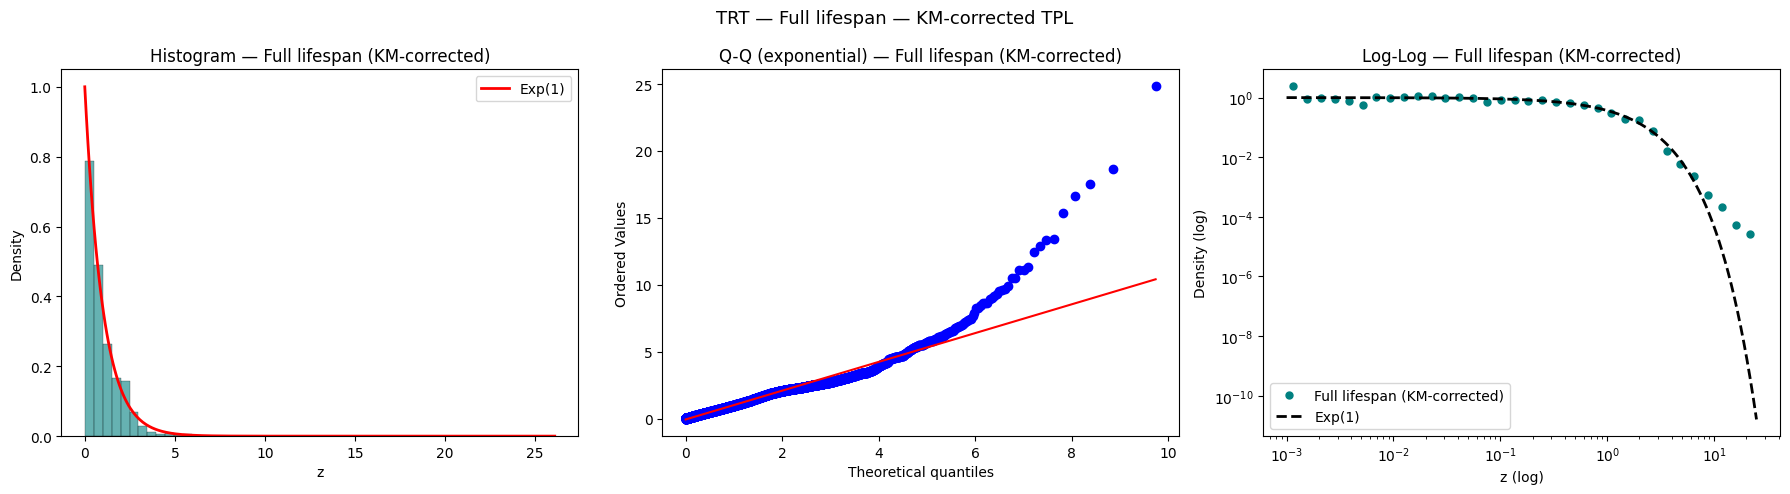

In [11]:
z_full_km, ks_full_km, ks_p_full_km, n_tail_full_km = apply_trt_km(
    iets_full, xmin_full, alpha_km_full, lam_km_full
)

print(f"Tail IETs: {n_tail_full_km}")
print(f"KS test vs Exp(1): D = {ks_full_km:.4f},  p = {ks_p_full_km:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_trt(z_full_km, 'Full lifespan (KM-corrected)', axes[0], axes[1], axes[2], color='teal')
plt.suptitle('TRT — Full lifespan — KM-corrected TPL', fontsize=13)
plt.tight_layout()
plt.show()

---
# Condition 2 — Year 2024 (Jan 1 – Dec 31)

In [12]:
df_2024 = conditions['Year 2024']
iets_2024 = compute_iets(df_2024)

print(f"IETs: {len(iets_2024):,}")
print(f"Mean: {iets_2024.mean():.1f} s  |  Median: {np.median(iets_2024):.1f} s")
print(f"Min: {iets_2024.min():.1f} s  |  Max: {iets_2024.max():.1f} s")

IETs: 17,313
Mean: 1825.5 s  |  Median: 235.0 s
Min: 1.0 s  |  Max: 78874.0 s


### 2a — Raw TPL fit

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


α = 1.5048   λ = 0.000030   xmin = 3061.0 s


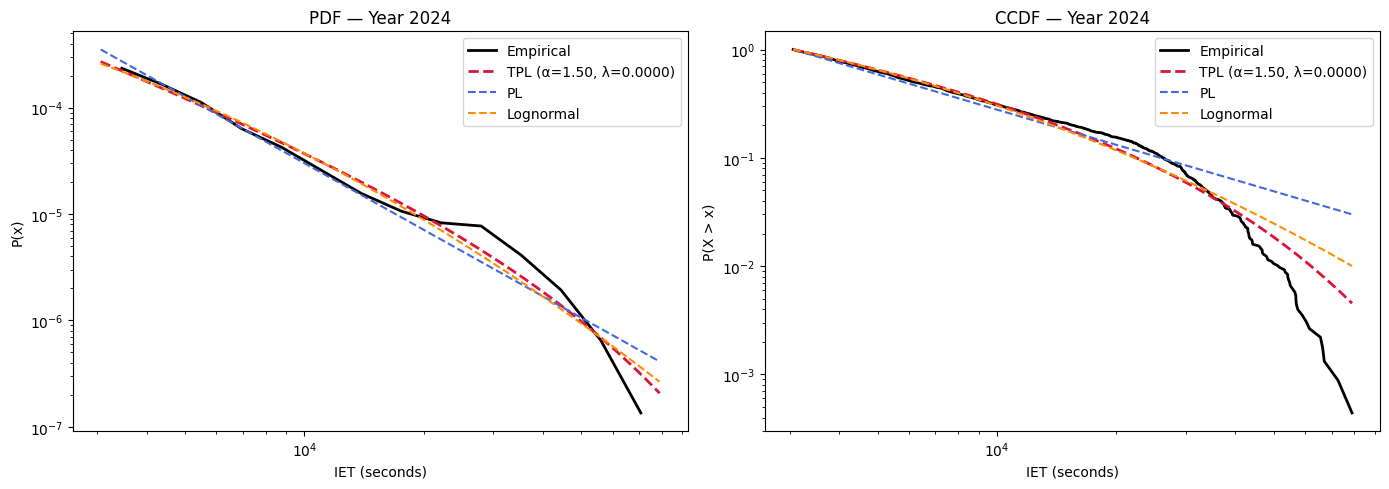

In [13]:
fit_2024, tpl_2024 = fit_tpl(iets_2024)

alpha_2024 = getattr(tpl_2024, 'alpha', np.nan)
lambda_2024 = getattr(tpl_2024, 'Lambda', np.nan)
xmin_2024 = float(getattr(tpl_2024, 'xmin', np.nan))

print(f"α = {alpha_2024:.4f}   λ = {lambda_2024:.6f}   xmin = {xmin_2024:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fit_2024.plot_pdf(color='black', lw=2, label='Empirical', ax=axes[0])
tpl_2024.plot_pdf(color='crimson', linestyle='--', lw=2,
                  label=f'TPL (α={alpha_2024:.2f}, λ={lambda_2024:.4f})', ax=axes[0])
fit_2024.power_law.plot_pdf(color='royalblue', linestyle='--', lw=1.5, label='PL', ax=axes[0])
fit_2024.lognormal.plot_pdf(color='darkorange', linestyle='--', lw=1.5, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('IET (seconds)')
axes[0].set_ylabel('P(x)')
axes[0].set_title('PDF — Year 2024')
axes[0].legend()

fit_2024.plot_ccdf(color='black', lw=2, label='Empirical', ax=axes[1])
tpl_2024.plot_ccdf(color='crimson', linestyle='--', lw=2,
                   label=f'TPL (α={alpha_2024:.2f}, λ={lambda_2024:.4f})', ax=axes[1])
fit_2024.power_law.plot_ccdf(color='royalblue', linestyle='--', lw=1.5, label='PL', ax=axes[1])
fit_2024.lognormal.plot_ccdf(color='darkorange', linestyle='--', lw=1.5, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('IET (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF — Year 2024')
axes[1].legend()
plt.tight_layout()
plt.show()

### 2b — TRT (raw)

Tail IETs (>= xmin=3061.0 s): 2268
KS test vs Exp(1): D = 0.0369,  p = 0.0041


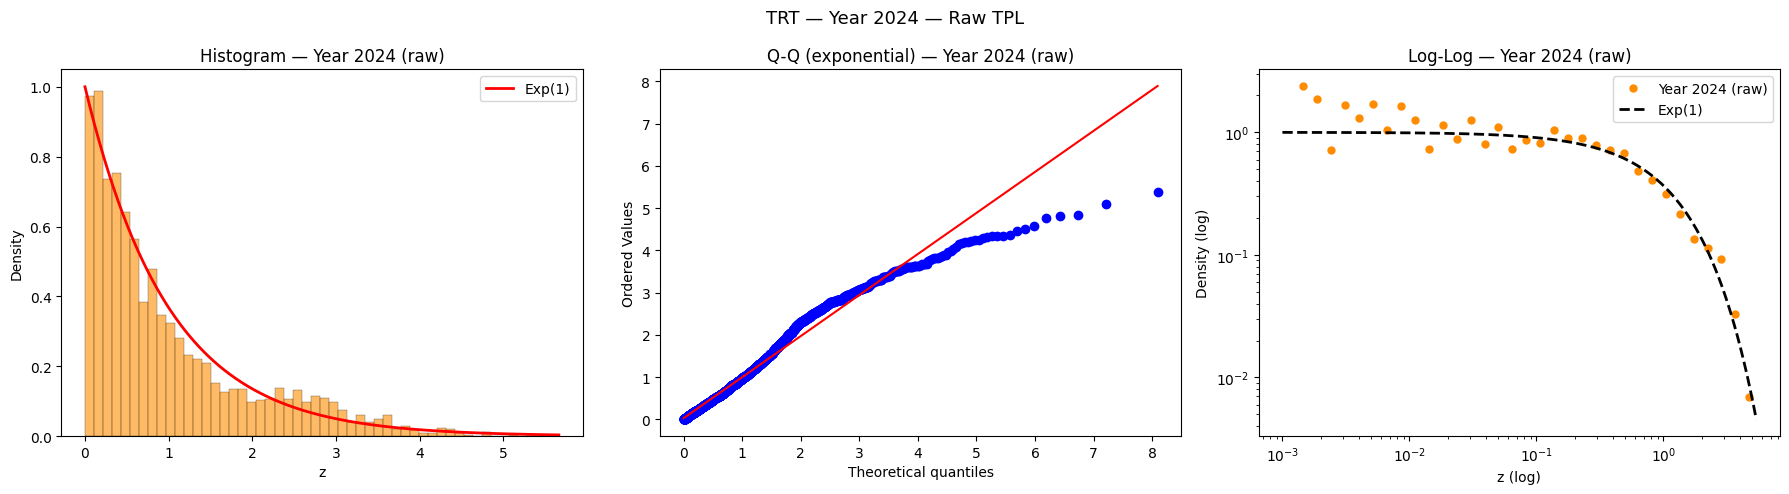

In [14]:
z_2024_raw, ks_2024_raw, ks_p_2024_raw, xmin_used_2024, n_tail_2024 = apply_trt(iets_2024, tpl_2024)

print(f"Tail IETs (>= xmin={xmin_used_2024:.1f} s): {n_tail_2024}")
print(f"KS test vs Exp(1): D = {ks_2024_raw:.4f},  p = {ks_p_2024_raw:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_trt(z_2024_raw, 'Year 2024 (raw)', axes[0], axes[1], axes[2], color='darkorange')
plt.suptitle('TRT — Year 2024 — Raw TPL', fontsize=13)
plt.tight_layout()
plt.show()

### 2c — KM finite-size-bias correction

KM-fitted TPL: α = 1.8598,  λ = 0.000022


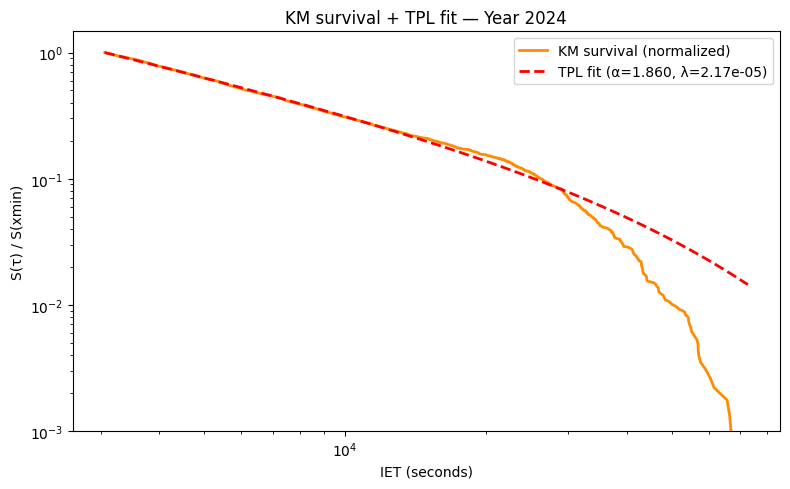

In [15]:
cutoff_2024 = df_2024['date'].max()
last_msg_2024 = df_2024['date'].iloc[-1]

km_t_2024, km_s_2024 = km_survival(iets_2024, cutoff_2024, last_msg_2024)
popt_2024, t_tail_2024 = fit_tpl_to_km(km_t_2024, km_s_2024, xmin_2024)

if popt_2024 is not None:
    alpha_km_2024, lam_km_2024 = popt_2024
    print(f"KM-fitted TPL: α = {alpha_km_2024:.4f},  λ = {lam_km_2024:.6f}")
else:
    print("KM TPL fit failed.")

if popt_2024 is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    mask_km = (km_t_2024 >= xmin_2024) & (km_s_2024 > 0)
    s_at_xmin_2024 = float(np.interp(xmin_2024, km_t_2024, km_s_2024))
    ax.plot(km_t_2024[mask_km], km_s_2024[mask_km] / s_at_xmin_2024,
            lw=2, color='darkorange', label='KM survival (normalized)')
    s_fit_2024 = (t_tail_2024 / xmin_2024) ** (-(alpha_km_2024 - 1)) * np.exp(-(t_tail_2024 - xmin_2024) * lam_km_2024)
    ax.plot(t_tail_2024, s_fit_2024, 'r--', lw=2,
            label=f'TPL fit (α={alpha_km_2024:.3f}, λ={lam_km_2024:.2e})')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-3)
    ax.set_xlabel('IET (seconds)')
    ax.set_ylabel('S(τ) / S(xmin)')
    ax.set_title('KM survival + TPL fit — Year 2024')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 2d — TRT (KM-corrected)

Tail IETs: 2268
KS test vs Exp(1): D = 0.0256,  p = 0.1016


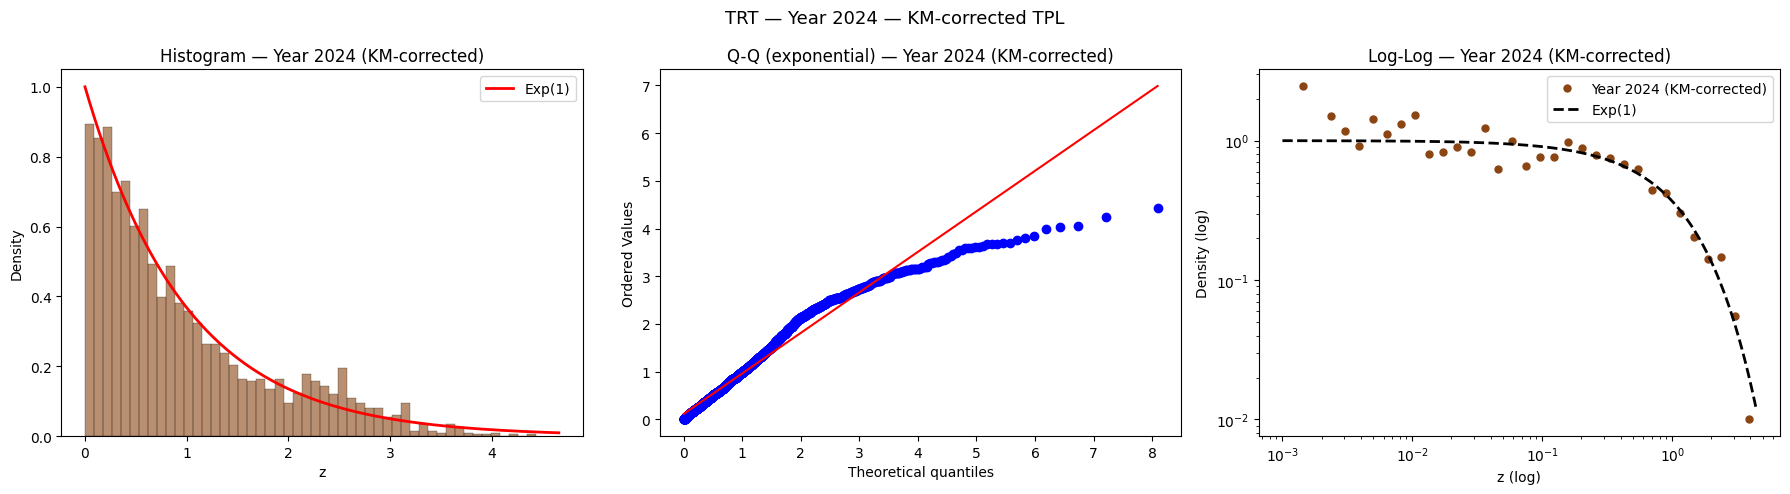

In [16]:
z_2024_km, ks_2024_km, ks_p_2024_km, n_tail_2024_km = apply_trt_km(
    iets_2024, xmin_2024, alpha_km_2024, lam_km_2024
)

print(f"Tail IETs: {n_tail_2024_km}")
print(f"KS test vs Exp(1): D = {ks_2024_km:.4f},  p = {ks_p_2024_km:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_trt(z_2024_km, 'Year 2024 (KM-corrected)', axes[0], axes[1], axes[2], color='saddlebrown')
plt.suptitle('TRT — Year 2024 — KM-corrected TPL', fontsize=13)
plt.tight_layout()
plt.show()

---
# Condition 3 — 2026 onwards (from Jan 15th 2026)

In [17]:
df_2026 = conditions['2026 onwards']
iets_2026 = compute_iets(df_2026)

print(f"IETs: {len(iets_2026):,}")
print(f"Mean: {iets_2026.mean():.1f} s  |  Median: {np.median(iets_2026):.1f} s")
print(f"Min: {iets_2026.min():.1f} s  |  Max: {iets_2026.max():.1f} s")

IETs: 15,357
Mean: 581.9 s  |  Median: 82.0 s
Min: 1.0 s  |  Max: 65093.0 s


### 3a — Raw TPL fit

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


α = 1.9022   λ = 0.000020   xmin = 1388.0 s


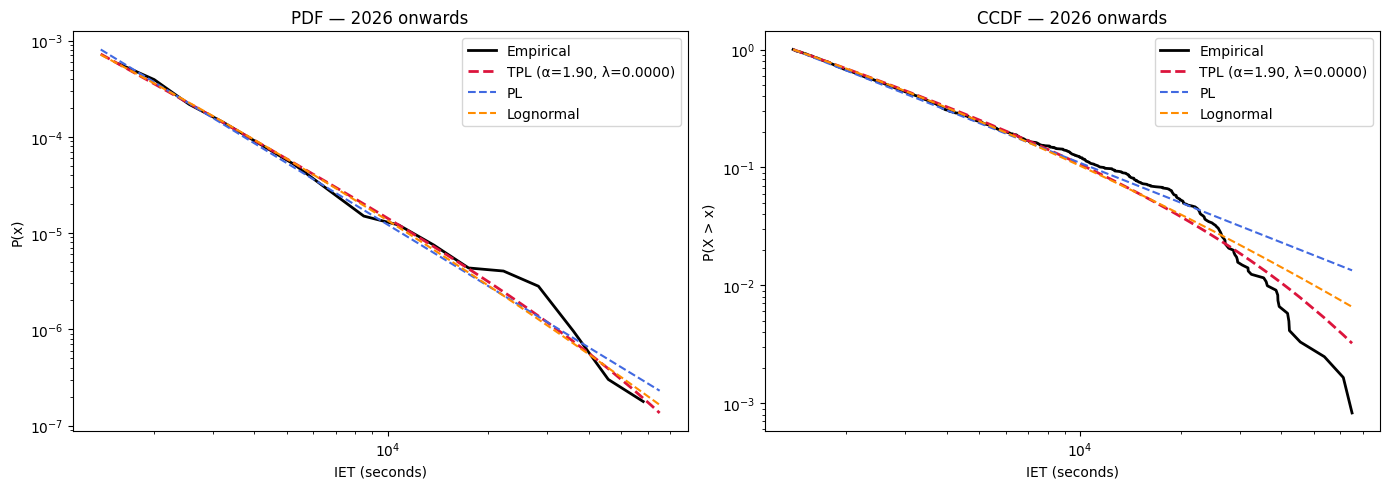

In [18]:
fit_2026, tpl_2026 = fit_tpl(iets_2026)

alpha_2026 = getattr(tpl_2026, 'alpha', np.nan)
lambda_2026 = getattr(tpl_2026, 'Lambda', np.nan)
xmin_2026 = float(getattr(tpl_2026, 'xmin', np.nan))

print(f"α = {alpha_2026:.4f}   λ = {lambda_2026:.6f}   xmin = {xmin_2026:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fit_2026.plot_pdf(color='black', lw=2, label='Empirical', ax=axes[0])
tpl_2026.plot_pdf(color='crimson', linestyle='--', lw=2,
                  label=f'TPL (α={alpha_2026:.2f}, λ={lambda_2026:.4f})', ax=axes[0])
fit_2026.power_law.plot_pdf(color='royalblue', linestyle='--', lw=1.5, label='PL', ax=axes[0])
fit_2026.lognormal.plot_pdf(color='darkorange', linestyle='--', lw=1.5, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('IET (seconds)')
axes[0].set_ylabel('P(x)')
axes[0].set_title('PDF — 2026 onwards')
axes[0].legend()

fit_2026.plot_ccdf(color='black', lw=2, label='Empirical', ax=axes[1])
tpl_2026.plot_ccdf(color='crimson', linestyle='--', lw=2,
                   label=f'TPL (α={alpha_2026:.2f}, λ={lambda_2026:.4f})', ax=axes[1])
fit_2026.power_law.plot_ccdf(color='royalblue', linestyle='--', lw=1.5, label='PL', ax=axes[1])
fit_2026.lognormal.plot_ccdf(color='darkorange', linestyle='--', lw=1.5, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('IET (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF — 2026 onwards')
axes[1].legend()
plt.tight_layout()
plt.show()

### 3b — TRT (raw)

Tail IETs (>= xmin=1388.0 s): 1212
KS test vs Exp(1): D = 0.0223,  p = 0.5760


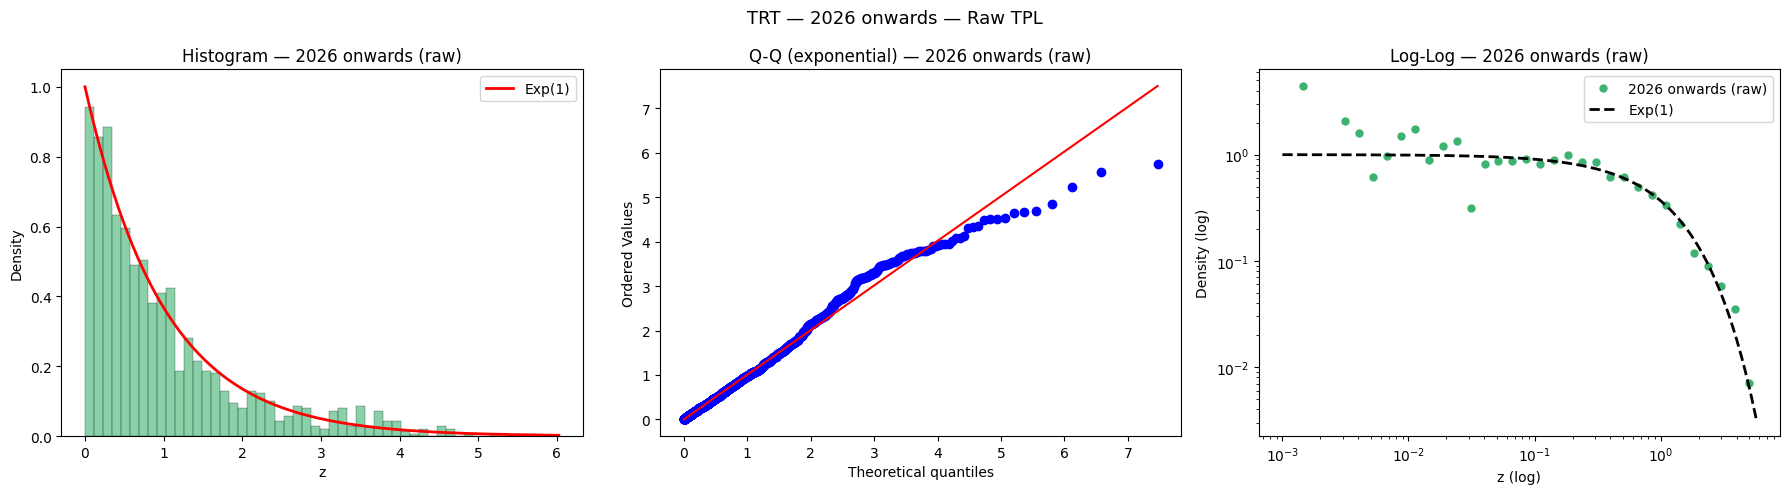

In [19]:
z_2026_raw, ks_2026_raw, ks_p_2026_raw, xmin_used_2026, n_tail_2026 = apply_trt(iets_2026, tpl_2026)

print(f"Tail IETs (>= xmin={xmin_used_2026:.1f} s): {n_tail_2026}")
print(f"KS test vs Exp(1): D = {ks_2026_raw:.4f},  p = {ks_p_2026_raw:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_trt(z_2026_raw, '2026 onwards (raw)', axes[0], axes[1], axes[2], color='mediumseagreen')
plt.suptitle('TRT — 2026 onwards — Raw TPL', fontsize=13)
plt.tight_layout()
plt.show()

### 3c — KM finite-size-bias correction

KM-fitted TPL: α = 2.0517,  λ = 0.000012


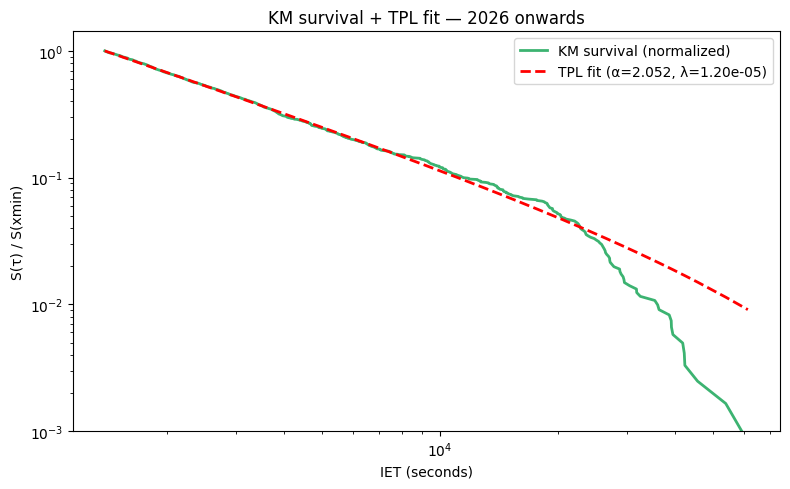

In [20]:
cutoff_2026 = df_2026['date'].max()
last_msg_2026 = df_2026['date'].iloc[-1]

km_t_2026, km_s_2026 = km_survival(iets_2026, cutoff_2026, last_msg_2026)
popt_2026, t_tail_2026 = fit_tpl_to_km(km_t_2026, km_s_2026, xmin_2026)

if popt_2026 is not None:
    alpha_km_2026, lam_km_2026 = popt_2026
    print(f"KM-fitted TPL: α = {alpha_km_2026:.4f},  λ = {lam_km_2026:.6f}")
else:
    print("KM TPL fit failed.")

if popt_2026 is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    mask_km = (km_t_2026 >= xmin_2026) & (km_s_2026 > 0)
    s_at_xmin_2026 = float(np.interp(xmin_2026, km_t_2026, km_s_2026))
    ax.plot(km_t_2026[mask_km], km_s_2026[mask_km] / s_at_xmin_2026,
            lw=2, color='mediumseagreen', label='KM survival (normalized)')
    s_fit_2026 = (t_tail_2026 / xmin_2026) ** (-(alpha_km_2026 - 1)) * np.exp(-(t_tail_2026 - xmin_2026) * lam_km_2026)
    ax.plot(t_tail_2026, s_fit_2026, 'r--', lw=2,
            label=f'TPL fit (α={alpha_km_2026:.3f}, λ={lam_km_2026:.2e})')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-3)
    ax.set_xlabel('IET (seconds)')
    ax.set_ylabel('S(τ) / S(xmin)')
    ax.set_title('KM survival + TPL fit — 2026 onwards')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 3d — TRT (KM-corrected)

Tail IETs: 1212
KS test vs Exp(1): D = 0.0145,  p = 0.9587


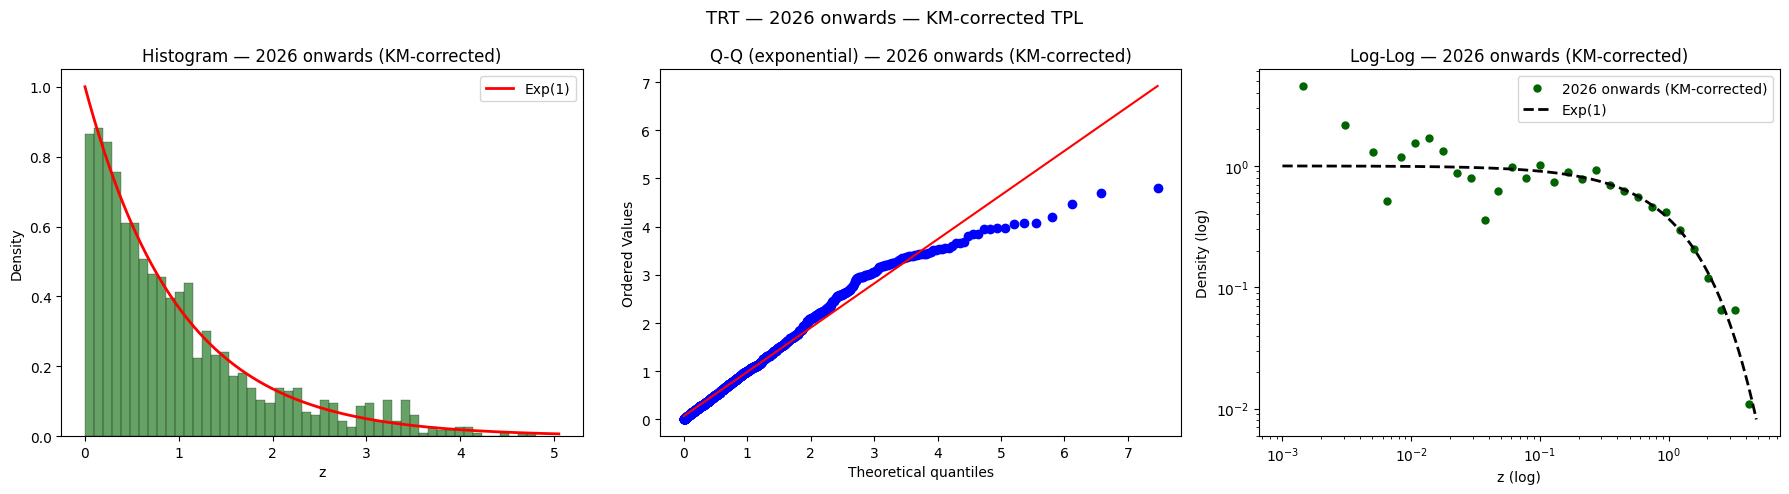

In [21]:
z_2026_km, ks_2026_km, ks_p_2026_km, n_tail_2026_km = apply_trt_km(
    iets_2026, xmin_2026, alpha_km_2026, lam_km_2026
)

print(f"Tail IETs: {n_tail_2026_km}")
print(f"KS test vs Exp(1): D = {ks_2026_km:.4f},  p = {ks_p_2026_km:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_trt(z_2026_km, '2026 onwards (KM-corrected)', axes[0], axes[1], axes[2], color='darkgreen')
plt.suptitle('TRT — 2026 onwards — KM-corrected TPL', fontsize=13)
plt.tight_layout()
plt.show()

---
# Summary — All 6 TRT distributions

In [22]:
summary = pd.DataFrame([
    {
        'Condition': 'Full lifespan',
        'Method': 'Raw TPL',
        'n_tail': n_tail_full,
        'alpha': alpha_full,
        'lambda': lambda_full,
        'xmin (s)': xmin_full,
        'KS statistic': ks_full_raw,
        'KS p-value': ks_p_full_raw,
    },
    {
        'Condition': 'Full lifespan',
        'Method': 'KM-corrected',
        'n_tail': n_tail_full_km,
        'alpha': alpha_km_full,
        'lambda': lam_km_full,
        'xmin (s)': xmin_full,
        'KS statistic': ks_full_km,
        'KS p-value': ks_p_full_km,
    },
    {
        'Condition': 'Year 2024',
        'Method': 'Raw TPL',
        'n_tail': n_tail_2024,
        'alpha': alpha_2024,
        'lambda': lambda_2024,
        'xmin (s)': xmin_2024,
        'KS statistic': ks_2024_raw,
        'KS p-value': ks_p_2024_raw,
    },
    {
        'Condition': 'Year 2024',
        'Method': 'KM-corrected',
        'n_tail': n_tail_2024_km,
        'alpha': alpha_km_2024,
        'lambda': lam_km_2024,
        'xmin (s)': xmin_2024,
        'KS statistic': ks_2024_km,
        'KS p-value': ks_p_2024_km,
    },
    {
        'Condition': '2026 onwards',
        'Method': 'Raw TPL',
        'n_tail': n_tail_2026,
        'alpha': alpha_2026,
        'lambda': lambda_2026,
        'xmin (s)': xmin_2026,
        'KS statistic': ks_2026_raw,
        'KS p-value': ks_p_2026_raw,
    },
    {
        'Condition': '2026 onwards',
        'Method': 'KM-corrected',
        'n_tail': n_tail_2026_km,
        'alpha': alpha_km_2026,
        'lambda': lam_km_2026,
        'xmin (s)': xmin_2026,
        'KS statistic': ks_2026_km,
        'KS p-value': ks_p_2026_km,
    },
])

display(summary)

,Condition,Method,n_tail,alpha,lambda,xmin (s),KS statistic,KS p-value
0,Full lifespan,Raw TPL,11796,1.748642,0.000003,2360.0,0.021012,0.000059
1,Full lifespan,KM-corrected,11796,1.772671,0.000008,2360.0,0.017805,0.001116
2,Year 2024,Raw TPL,2268,1.504785,0.000030,3061.0,0.036858,0.004108
3,Year 2024,KM-corrected,2268,1.859765,0.000022,3061.0,0.025555,0.101627
4,2026 onwards,Raw TPL,1212,1.902161,0.000020,1388.0,0.022286,0.576007
5,2026 onwards,KM-corrected,1212,2.051700,0.000012,1388.0,0.014455,0.958665


In [23]:
# Paper-ready: all 6 TRT distributions — VagarenFe
import seaborn as sns
import matplotlib as mpl

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7.5, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

palette = {
    ('Full lifespan', 'Raw TPL'):      ('steelblue',       'o', '-',  'Full lifespan — Raw'),
    ('Full lifespan', 'KM-corrected'): ('teal',            's', '--', 'Full lifespan — KM'),
    ('Year 2024',     'Raw TPL'):      ('darkorange',      'o', '-',  'Year 2024 — Raw'),
    ('Year 2024',     'KM-corrected'): ('saddlebrown',     's', '--', 'Year 2024 — KM'),
    ('2026 onwards',  'Raw TPL'):      ('mediumseagreen',  'o', '-',  '2026 onwards — Raw'),
    ('2026 onwards',  'KM-corrected'): ('darkgreen',       's', '--', '2026 onwards — KM'),
}

all_z = [
    (z_full_raw,  'Full lifespan', 'Raw TPL'),
    (z_full_km,   'Full lifespan', 'KM-corrected'),
    (z_2024_raw,  'Year 2024',     'Raw TPL'),
    (z_2024_km,   'Year 2024',     'KM-corrected'),
    (z_2026_raw,  '2026 onwards',  'Raw TPL'),
    (z_2026_km,   '2026 onwards',  'KM-corrected'),
]

fig, ax = plt.subplots(figsize=(4.5, 3.5))

z_max_global = 0
for z, cond, method in all_z:
    z_pos = z[(z > 0) & np.isfinite(z)]
    if z_pos.size < 10:
        continue
    z_max_global = max(z_max_global, np.max(z_pos))
    z_min_pos = max(np.min(z_pos), 1e-3)
    bins = np.logspace(np.log10(z_min_pos), np.log10(np.max(z_pos)), 30)
    hist, edges = np.histogram(z_pos, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])
    mask = hist > 0
    color, marker, ls, label = palette[(cond, method)]
    ax.plot(centers[mask], hist[mask], marker=marker, linestyle='none',
            ms=3, alpha=0.8, color=color, label=label)

x_ref = np.logspace(-3, np.log10(max(8, z_max_global)), 400)
ax.plot(x_ref, stats.expon.pdf(x_ref, scale=1), 'k--', lw=1.5, label='Exp(1) PDF')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('z (log scale)')
ax.set_ylabel('Density (log scale)')
ax.legend(ncol=1, loc='lower left', framealpha=0.9)
ax.grid(True, alpha=0.25, linewidth=0.5)

fig.savefig('paper_trt_all_conditions_renfe.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved paper_trt_all_conditions_renfe.pdf')


In [24]:
# Per-channel KM-corrected rescaling — RENFE 2024 and 2026
import matplotlib.cm as cm

MIN_IETS = 30  # skip channels with fewer tail IETs

tab20 = cm.get_cmap('tab20')


def per_channel_km_rescaling(df_period, cutoff_ts, label='', min_iets=MIN_IETS):
    results = {}
    counts = df_period['topic_name'].value_counts()
    eligible = counts[counts >= min_iets].index.tolist()
    for ch in sorted(eligible):
        ch_df = df_period[df_period['topic_name'] == ch].sort_values('date')
        iets = compute_iets(ch_df)
        if len(iets) < min_iets:
            continue
        last_msg = ch_df['date'].iloc[-1]
        km_t, km_s = km_survival(iets, cutoff_ts, last_msg)
        fit_raw, _ = fit_tpl(iets)
        xmin = float(fit_raw.truncated_power_law.xmin)
        popt, _ = fit_tpl_to_km(km_t, km_s, xmin)
        if popt is None:
            print(f"  [{label}] Skipping {ch}: KM TPL fit failed")
            continue
        alpha_km, lam_km = popt
        z, ks_stat, ks_p, n_tail = apply_trt_km(iets, xmin, alpha_km, lam_km)
        results[ch] = {'z': z, 'n_tail': n_tail,
                       'alpha': alpha_km, 'lambda': lam_km,
                       'ks_stat': ks_stat, 'ks_p': ks_p}
        print(f"  {ch}: alpha={alpha_km:.3f}, n_tail={n_tail}, KS p={ks_p:.3f}")
    return results


print("=== RENFE 2024 — per channel ===")
km_results_2024_ch = per_channel_km_rescaling(df_2024, df_2024['date'].max(), label='2024')

print("\n=== RENFE 2026 — per channel ===")
km_results_2026_ch = per_channel_km_rescaling(df_2026, df_2026['date'].max(), label='2026')

# Consistent color map across both periods
all_ch = sorted(set(km_results_2024_ch) | set(km_results_2026_ch))
channel_colors_renfe = {ch: tab20(i % 20) for i, ch in enumerate(all_ch)}

print(f"\nChannels — 2024: {len(km_results_2024_ch)}, 2026: {len(km_results_2026_ch)}")


/var/folders/t0/sjtcv6y97xnczv424tb3c5yc0000gn/T/ipykernel_61864/1616292374.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = cm.get_cmap('tab20')


=== RENFE 2024 — per channel ===


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

  General: alpha=1.215, n_tail=308, KS p=0.860
  Hemeroteca: alpha=2.878, n_tail=66, KS p=0.974


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


...

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


  R2Nord R11: alpha=2.835, n_tail=96, KS p=0.982


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

  R2Sud i RegSud: alpha=1.591, n_tail=783, KS p=0.829
  R3 INFO, desdoblament: alpha=1.439, n_tail=74, KS p=0.934
  R4 RL4: alpha=1.951, n_tail=92, KS p=0.986
  R7 i R8: alpha=1.351, n_tail=229, KS p=0.959

Channels — 2024: 9, 2026: 11


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

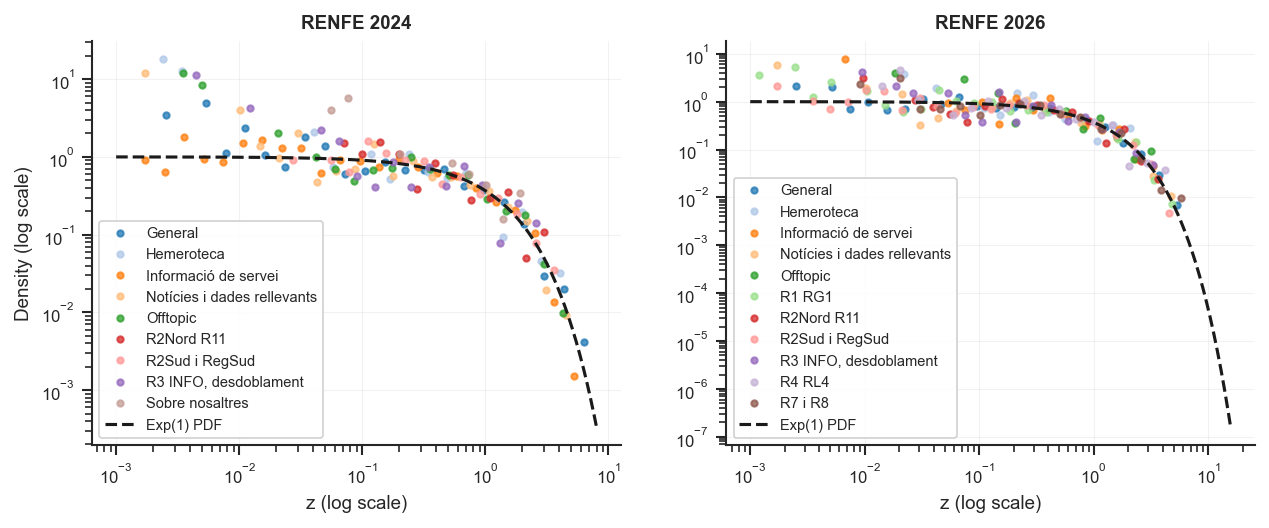

Saved paper_km_rescaled_renfe.pdf


In [26]:
# Paper-ready: KM-corrected rescaled intervals — RENFE 2024 vs 2026 (log-log)
import seaborn as sns
import matplotlib as mpl

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

panels = [
    (axes[0], km_results_2024_ch, 'RENFE 2024'),
    (axes[1], km_results_2026_ch, 'RENFE 2026'),
]

for ax, km_results, title in panels:
    z_max_global = 1.0
    for channel, out in km_results.items():
        z_ch = np.asarray(out['z'], dtype=float)
        z_ch = z_ch[np.isfinite(z_ch) & (z_ch > 0)]
        if z_ch.size < 10:
            continue
        z_min = max(np.min(z_ch), 1e-3)
        z_max = np.max(z_ch)
        if z_max <= z_min:
            continue
        z_max_global = max(z_max_global, z_max)
        bins = np.logspace(np.log10(z_min), np.log10(z_max), 25)
        hist, edges = np.histogram(z_ch, bins=bins, density=True)
        centers = np.sqrt(edges[:-1] * edges[1:])
        mask = hist > 0
        ax.plot(centers[mask], hist[mask],
                marker='o', linestyle='none', ms=3, alpha=0.75,
                label=channel, color=channel_colors_renfe[channel])

    x = np.logspace(-3, np.log10(max(8, z_max_global)), 400)
    ax.plot(x, stats.expon.pdf(x, scale=1), 'k--', lw=1.5, label='Exp(1) PDF')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('z (log scale)')
    ax.set_title(title, fontweight='bold', pad=6)
    ax.grid(True, alpha=0.25, linewidth=0.5)
    ax.legend(ncol=1, loc='lower left', framealpha=0.9)

axes[0].set_ylabel('Density (log scale)')

fig.savefig('paper_km_rescaled_renfe.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved paper_km_rescaled_renfe.pdf')


In [27]:
# Per-channel raw TRT rescaling (no KM correction) — RENFE 2024 and 2026
def per_channel_raw_rescaling(df_period, min_iets=MIN_IETS):
    results = {}
    counts = df_period['topic_name'].value_counts()
    eligible = counts[counts >= min_iets].index.tolist()
    for ch in sorted(eligible):
        ch_df = df_period[df_period['topic_name'] == ch].sort_values('date')
        iets = compute_iets(ch_df)
        if len(iets) < min_iets:
            continue
        _, tpl = fit_tpl(iets)
        z, ks_stat, ks_p, xmin, n_tail = apply_trt(iets, tpl)
        if n_tail < 10:
            continue
        results[ch] = {'z': z, 'n_tail': n_tail, 'ks_stat': ks_stat, 'ks_p': ks_p}
        print(f"  {ch}: n_tail={n_tail}, KS p={ks_p:.3f}")
    return results

print("=== RENFE 2024 — raw TRT per channel ===")
raw_results_2024_ch = per_channel_raw_rescaling(df_2024)

print("\n=== RENFE 2026 — raw TRT per channel ===")
raw_results_2026_ch = per_channel_raw_rescaling(df_2026)

print(f"\nRaw — 2024: {len(raw_results_2024_ch)} channels, 2026: {len(raw_results_2026_ch)} channels")


=== RENFE 2024 — raw TRT per channel ===


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


  General: n_tail=308, KS p=0.821


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


  Hemeroteca: n_tail=66, KS p=0.917


...

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


  R2Sud i RegSud: n_tail=783, KS p=0.273
  R3 INFO, desdoblament: n_tail=74, KS p=0.924


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


  R4 RL4: n_tail=92, KS p=0.973
  R7 i R8: n_tail=229, KS p=0.969

Raw — 2024: 9 channels, 2026: 11 channels


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

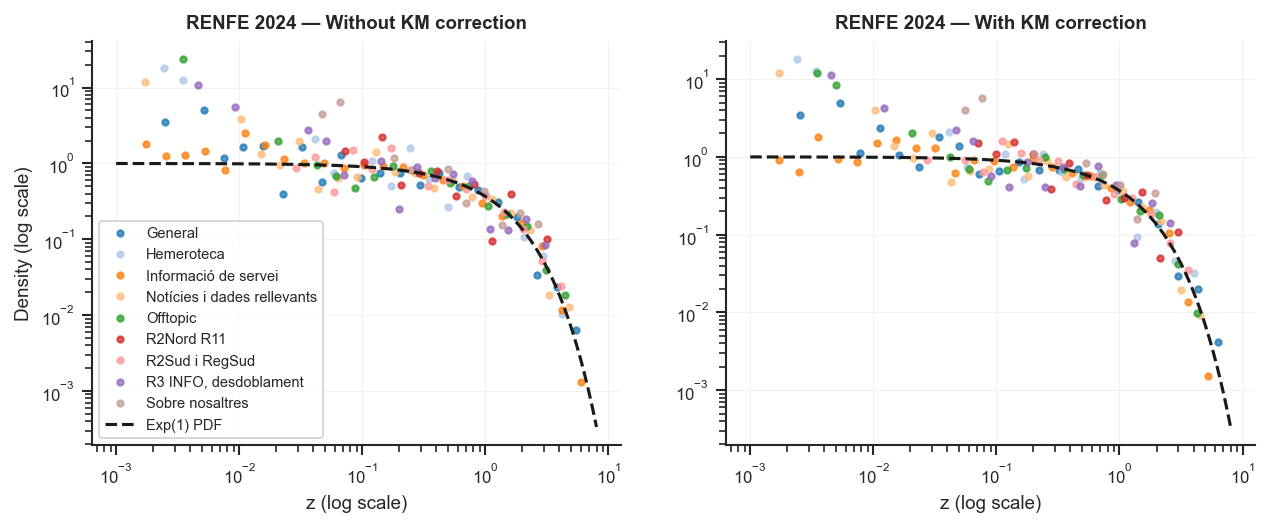

Saved paper_trt_raw_vs_km_renfe_2024.pdf


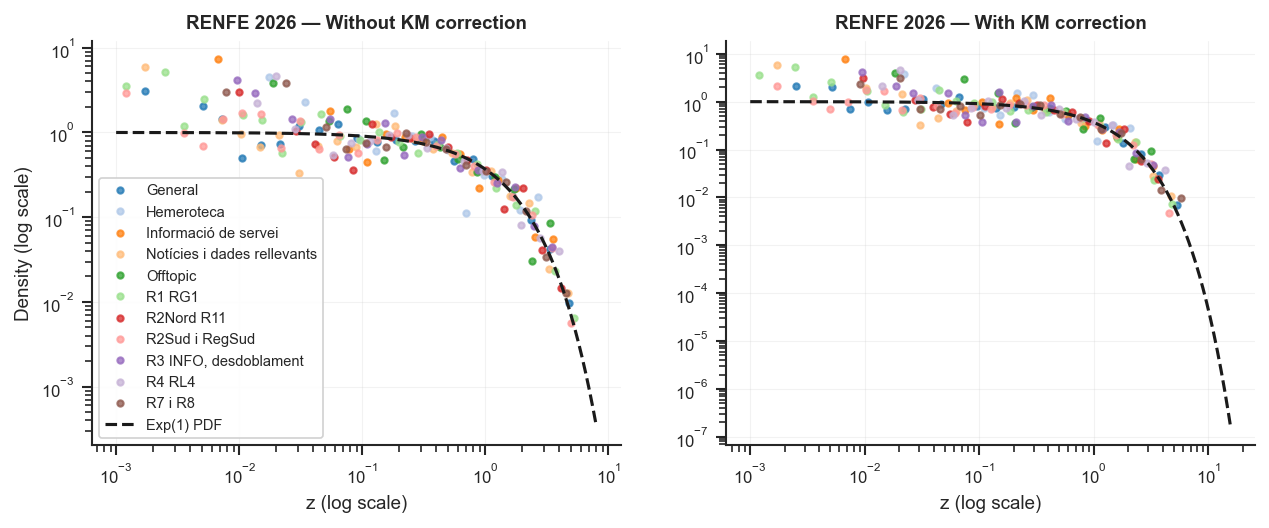

Saved paper_trt_raw_vs_km_renfe_2026.pdf


In [28]:
# Paper-ready: raw vs KM TRT — RENFE 2024 and 2026 (two separate figures)
import seaborn as sns
import matplotlib as mpl

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})


def plot_trt_panel(ax, results, title, colors, show_legend=False):
    z_max_global = 1.0
    for channel, out in results.items():
        z_ch = np.asarray(out['z'], dtype=float)
        z_ch = z_ch[np.isfinite(z_ch) & (z_ch > 0)]
        if z_ch.size < 10:
            continue
        z_min = max(np.min(z_ch), 1e-3)
        z_max = np.max(z_ch)
        if z_max <= z_min:
            continue
        z_max_global = max(z_max_global, z_max)
        bins = np.logspace(np.log10(z_min), np.log10(z_max), 25)
        hist, edges = np.histogram(z_ch, bins=bins, density=True)
        centers = np.sqrt(edges[:-1] * edges[1:])
        mask = hist > 0
        ax.plot(centers[mask], hist[mask],
                marker='o', linestyle='none', ms=3, alpha=0.75,
                label=channel, color=colors[channel])
    x = np.logspace(-3, np.log10(max(8, z_max_global)), 400)
    ax.plot(x, stats.expon.pdf(x, scale=1), 'k--', lw=1.5, label='Exp(1) PDF')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('z (log scale)')
    ax.set_title(title, fontweight='bold', pad=6)
    ax.grid(True, alpha=0.25, linewidth=0.5)
    if show_legend:
        ax.legend(ncol=1, loc='lower left', framealpha=0.9)


for (raw, km, year, fname) in [
    (raw_results_2024_ch, km_results_2024_ch, '2024', 'paper_trt_raw_vs_km_renfe_2024.pdf'),
    (raw_results_2026_ch, km_results_2026_ch, '2026', 'paper_trt_raw_vs_km_renfe_2026.pdf'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    plot_trt_panel(axes[0], raw, f'RENFE {year} — Without KM correction',
                   channel_colors_renfe, show_legend=True)
    plot_trt_panel(axes[1], km,  f'RENFE {year} — With KM correction',
                   channel_colors_renfe, show_legend=False)
    axes[0].set_ylabel('Density (log scale)')
    fig.savefig(fname, format='pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')
